In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [10]:
df = pd.read_csv("../data/fifa_world_cup_2026_player_performance.csv")
df.head()

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


In [11]:
df.tail()

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
54595,P00996,Amir Younis,28,Iraqi,Iraq,8,Defender,177,73,Right,...,0.0,41.9,27.7,31.3,40.5,1,0,97,0,0.0
54596,P01006,Safaa Al-Khafaji,20,Iraqi,Iraq,18,Midfielder,176,72,Right,...,0.0,64.2,53.1,64.8,64.3,2,0,206,0,0.0
54597,P01008,Ahmed Hussein,26,Iraqi,Iraq,20,Midfielder,173,77,Left,...,0.0,75.4,55.0,65.0,64.5,1,1,359,0,0.0
54598,P00991,Ibrahim Mhawi,30,Iraqi,Iraq,3,Goalkeeper,190,81,Right,...,0.0,96.3,39.6,99.0,99.0,0,0,342,0,0.0
54599,P00989,Mohannad Hussein,27,Iraqi,Iraq,1,Goalkeeper,187,73,Right,...,0.0,99.0,34.1,99.0,99.0,0,0,286,0,0.0


In [13]:
df.shape

(54600, 75)

In [14]:
df.columns

Index(['player_id', 'player_name', 'age', 'nationality', 'team',
       'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot',
       'club_name', 'market_value_eur', 'match_id', 'match_date', 'stadium',
       'city', 'opponent_team', 'tournament_stage', 'match_result',
       'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists',
       'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa',
       'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy',
       'dribbles_attempted', 'successful_dribbles', 'crosses',
       'successful_crosses', 'tackles', 'interceptions', 'clearances',
       'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries',
       'defensive_actions', 'fouls_committed', 'fouls_suffered',
       'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage',
       'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves',
       'distance_covered_km', 'sprint_distance_km', 'top_speed_k

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  str    
 1   player_name               54600 non-null  str    
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  str    
 4   team                      54600 non-null  str    
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  str    
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  str    
 10  club_name                 54600 non-null  str    
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  str    
 13  match_date                54600 non-null  str    
 14  stadium          

In [16]:
df.describe()

,age,jersey_number,height_cm,weight_kg,market_value_eur,goals_team,goals_opponent,minutes_played,goals,assists,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
count,54600.000000,54600.000000,54600.000000,54600.000000,5.460000e+04,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,...,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000
mean,26.296484,13.500000,181.654341,75.754853,2.008445e+07,1.330476,1.330476,36.199817,0.055385,0.052363,...,2.850165,60.318379,46.135778,63.750396,55.572154,0.643993,0.607601,272.300311,0.030659,3.634046
std,4.067519,7.500069,6.277792,3.951481,2.718866e+07,1.147814,1.147814,36.419755,0.251900,0.239021,...,4.228436,20.234988,22.424337,19.860028,13.661343,1.093781,0.931527,116.806184,0.206520,3.163411
min,17.000000,1.000000,163.000000,65.000000,5.288220e+05,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,15.000000,5.000000,25.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,7.000000,177.000000,73.000000,4.444778e+06,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,43.700000,29.800000,46.500000,46.400000,0.000000,0.000000,184.000000,0.000000,0.000000
50%,26.000000,13.500000,182.000000,76.000000,1.027111e+07,1.000000,1.000000,24.000000,0.000000,0.000000,...,1.100000,57.000000,40.500000,61.100000,55.000000,0.000000,0.000000,268.000000,0.000000,5.400000
75%,29.000000,20.000000,186.000000,78.000000,2.342013e+07,2.000000,2.000000,75.000000,0.000000,0.000000,...,4.000000,75.100000,59.000000,78.900000,63.900000,1.000000,1.000000,359.000000,0.000000,6.400000
max,39.000000,26.000000,200.000000,87.000000,2.000000e+08,7.000000,7.000000,90.000000,4.000000,3.000000,...,37.000000,99.000000,99.000000,99.000000,99.000000,10.000000,8.000000,615.000000,4.000000,9.500000


In [18]:
df.describe(include="object")

,player_id,player_name,nationality,team,position,preferred_foot,club_name,match_id,match_date,stadium,city,opponent_team,tournament_stage,match_result
count,54600,54600,54600,54600,54600,54600,54600,54600,54600,54600,54600,54600,54600,54600
unique,1248,1245,48,48,4,2,122,1050,51,16,16,48,7,3
top,P00937,Pierre-Emile Christensen,Qatari,Qatar,Defender,Right,Gor Mahia,M00001,2026-06-30,Lincoln Financial Field,Philadelphia,Qatar,Group Stage,W
freq,66,86,1716,1716,18900,40656,892,52,1560,4264,4264,1716,30056,20124


In [21]:

missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [ ]:

df.duplicated().sum()

np.int64(0)

In [23]:
df = df.drop_duplicates()

In [24]:
df.dtypes

player_id                       str
player_name                     str
age                           int64
nationality                     str
team                            str
                             ...   
total_goals_tournament        int64
total_assists_tournament      int64
total_minutes_tournament      int64
player_of_match_awards        int64
tournament_rating           float64
Length: 75, dtype: object

In [25]:
df["match_date"] = pd.to_datetime(df["match_date"])

In [26]:
df["match_date"].dtype

dtype('<M8[us]')

In [27]:
df["position"].unique()

<StringArray>
['Goalkeeper', 'Midfielder', 'Forward', 'Defender']
Length: 4, dtype: str

In [28]:
df["preferred_foot"].unique()

<StringArray>
['Left', 'Right']
Length: 2, dtype: str

In [29]:
df["tournament_stage"].unique()

<StringArray>
[      'Group Stage',       'Round of 32',       'Round of 16',
    'Quarter Finals',       'Semi Finals', 'Third Place Match',
             'Final']
Length: 7, dtype: str

In [38]:
df["match_result"].unique()

<StringArray>
['W', 'L', 'D']
Length: 3, dtype: str

In [44]:
df["team"].nunique()

48

In [39]:
df["age"].describe()

count    54600.000000
mean        26.296484
std          4.067519
min         17.000000
25%         23.000000
50%         26.000000
75%         29.000000
max         39.000000
Name: age, dtype: float64

In [40]:
df["minutes_played"].describe()

count    54600.000000
mean        36.199817
std         36.419755
min          0.000000
25%          0.000000
50%         24.000000
75%         75.000000
max         90.000000
Name: minutes_played, dtype: float64

In [41]:
df["pass_accuracy"].describe()

count    54600.000000
mean         0.808440
std          0.074286
min          0.420000
25%          0.760000
50%          0.820000
75%          0.860000
max          0.970000
Name: pass_accuracy, dtype: float64

In [42]:
df["player_rating"].describe()

count    54600.000000
mean         3.634700
std          3.155846
min          0.000000
25%          0.000000
50%          5.500000
75%          6.400000
max          9.400000
Name: player_rating, dtype: float64

In [43]:
df["top_speed_kmh"].describe()

count    54600.000000
mean        18.645636
std         16.016266
min          0.000000
25%          0.000000
50%         29.900000
75%         32.700000
max         37.000000
Name: top_speed_kmh, dtype: float64

In [45]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

print(f"Total Numerical Columns: {len(numerical_columns)}")
numerical_columns

Total Numerical Columns: 61


Index(['age', 'jersey_number', 'height_cm', 'weight_kg', 'market_value_eur',
       'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists',
       'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa',
       'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy',
       'dribbles_attempted', 'successful_dribbles', 'crosses',
       'successful_crosses', 'tackles', 'interceptions', 'clearances',
       'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries',
       'defensive_actions', 'fouls_committed', 'fouls_suffered',
       'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage',
       'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves',
       'distance_covered_km', 'sprint_distance_km', 'top_speed_kmh',
       'accelerations', 'decelerations', 'stamina_score', 'player_rating',
       'performance_score', 'offensive_contribution', 'defensive_contribution',
       'possession_impact', 'pressure_resistance', 'c

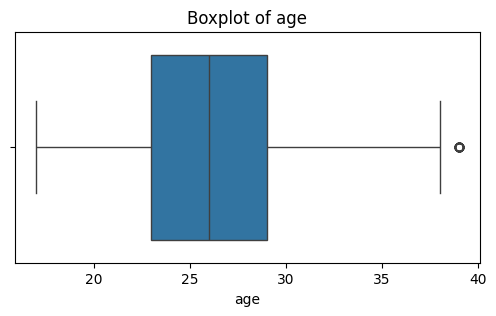

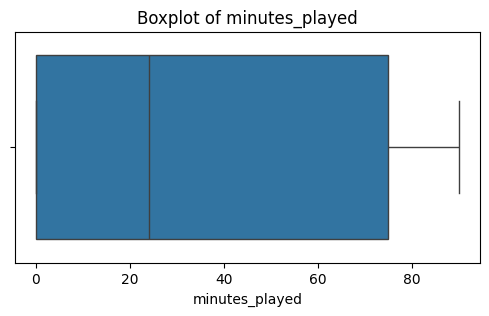

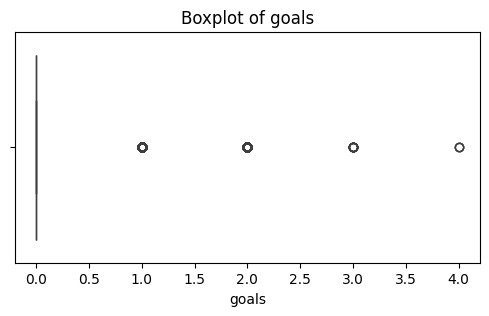

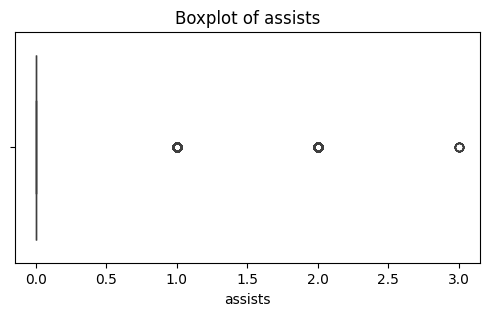

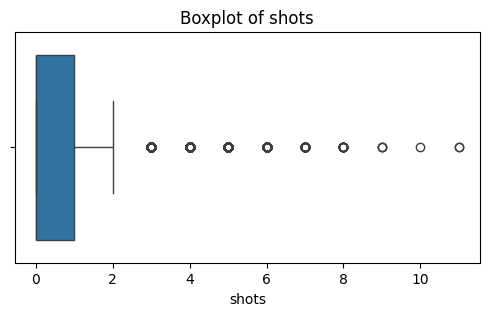

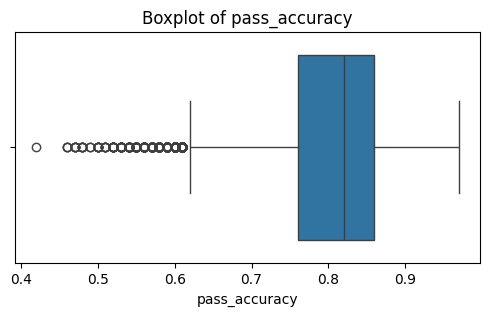

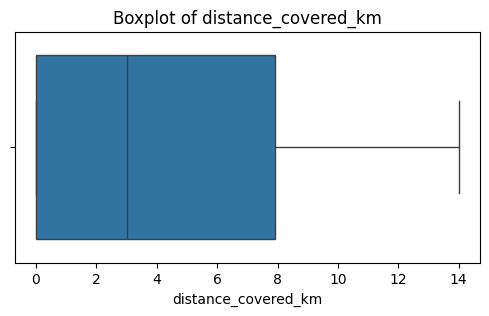

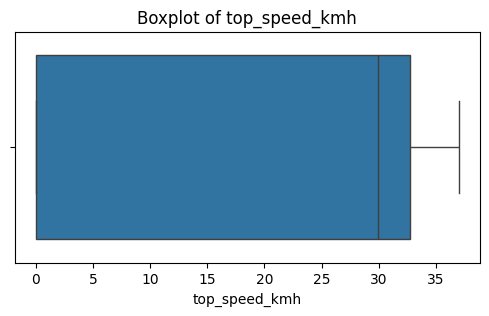

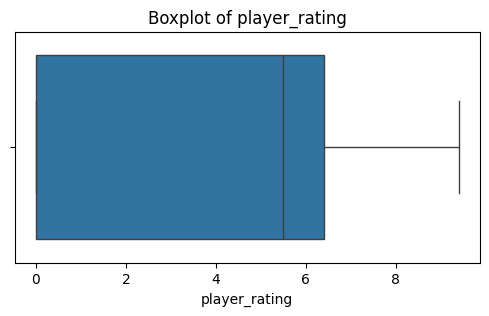

In [46]:
important_columns = [
    'age',
    'minutes_played',
    'goals',
    'assists',
    'shots',
    'pass_accuracy',
    'distance_covered_km',
    'top_speed_kmh',
    'player_rating'
]
import matplotlib.pyplot as plt
import seaborn as sns

for col in important_columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [47]:
df[['age',
    'minutes_played',
    'pass_accuracy',
    'top_speed_kmh',
    'player_rating']].describe()

,age,minutes_played,pass_accuracy,top_speed_kmh,player_rating
count,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000
mean,26.296484,36.199817,0.808440,18.645636,3.634700
std,4.067519,36.419755,0.074286,16.016266,3.155846
min,17.000000,0.000000,0.420000,0.000000,0.000000
25%,23.000000,0.000000,0.760000,0.000000,0.000000
50%,26.000000,24.000000,0.820000,29.900000,5.500000
75%,29.000000,75.000000,0.860000,32.700000,6.400000
max,39.000000,90.000000,0.970000,37.000000,9.400000


In [48]:
df.to_csv("../data/fifa_world_cup_2026_cleaned.csv", index=False)

• Verified missing values.
• Verified duplicate records.
• Converted match_date to datetime format.
• Checked categorical values.
• Inspected numerical ranges.
• Visualised outliers using boxplots.
• No significant cleaning was required.
• Saved cleaned dataset.